# iToF / Structured-Light Fusion Pipeline 

Calibration and depth fusion for a combined indirect Time-of-Flight (iToF) and Structured Light (SL) approach.
Based on:
- **Microsoft-Paper** – Godbaz et al. 2025 (Microsoft): dot calibration (4.1), 1-D dot trails, consistency error, active brightness trail (4.2)
- **Agresti** – Agresti & Zanuttigh, ECCV 2018: maximum likelihood depth fusion (eq. 16/17)


All heavy lifting lives in `dot_calibration.py`, `calibrate.py`
and `approaches.py`. So this notebook only orchestrates and visualizes.

In [1]:
from dot_calibration import DotCalibration
import approaches
import calibrate
import os
import numpy as np
from pathlib import Path
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import matplotlib.pyplot as plt

dotCal = DotCalibration()

# ── Camera / data selection / presets in calibrate.py
CAMERA = "SchmersalReal"          # "OnSemi" (Simulation) or "Schmersal" (Simulation) or "SchmersalReal" (First real measurement)
cfg     = calibrate.CAMERAS[CAMERA]
sl_cal  = cfg["sl_cal"]
tof_cal = cfg["tof_cal"]
K       = cfg["K"]          
CAL_BLOB_PARAMS = cfg["cal_blob"]
TOF_SAMPLE      = cfg.get("tof_sample")   # how to read ToF depth at a dot (see calibrate.CAMERAS)

K_inv = np.linalg.inv(K)
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

SUBPIXEL_MODE = "GPR"      # paper: LoG + GPR ("geometricCenter" as fallback)
TRACK_IN_TX_SPACE = False  # True: re-track in transmitter space (Godbaz 4.1)
BASELINE_OUTLIER_SIGMA = 3.0  # Godbaz: outlier-ray removal before the final Baseline fit
MIN_TRACK_POINTS = 3       # low-confidence invalidation: min distances per dot line
TRAIL_Z_MIN = 0.35          # trails run from here to infinity [m] (Godbaz: ~30 cm)

calibration_figures = []   # list of (name, fig)
print("Setup complete.")

Setup complete.


## Calibration Steps 1–2: Dot Detection, Subpixel Localisation & Tracking

LoG blob detection on each calibration SL image, followed by GPR
(Godbaz 4.1: LoG finds the area near the peak, a Gaussian-process model of the intensity
map is searched for the subpixel location). No fixed grid is assumed.

Stable IDs are then assigned by tracking each dot across the calibration distances with
a nearest-neighbor search; dots may enter/leave FOV between distances.

Calibration distances: [0.402, 0.439, 0.486, 0.545, 0.621, 0.72, 0.857, 1.059, 1.385, 2.0]
  Processing Pos0.exr …


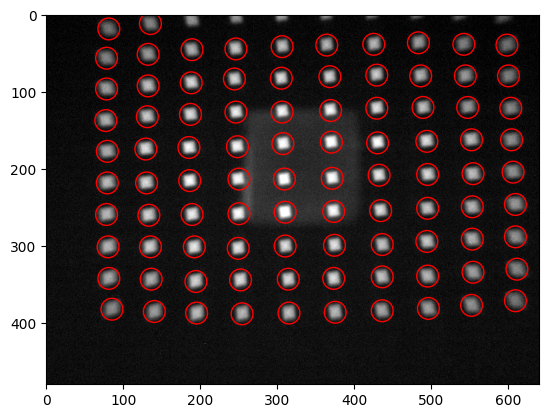

  Processing Pos1.exr …


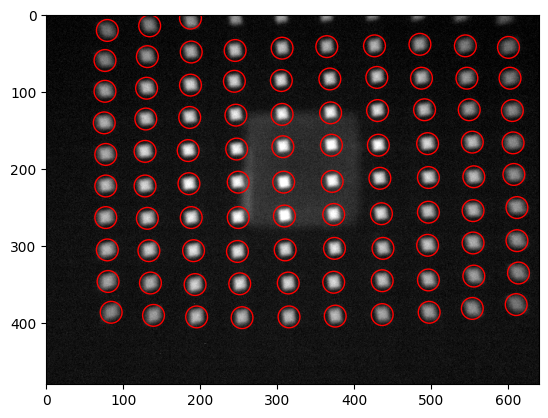

  Processing Pos2.exr …


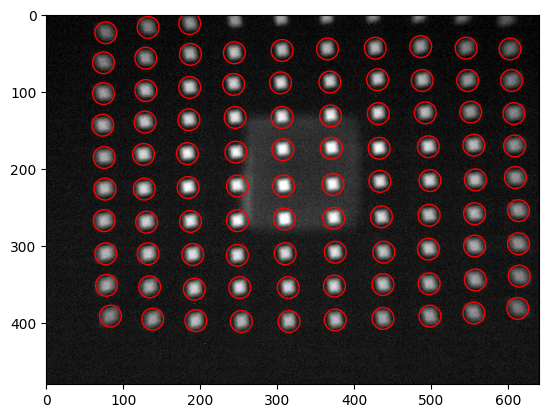

  Processing Pos3.exr …


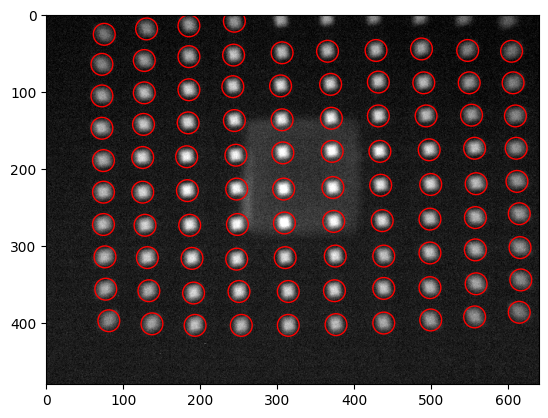

  Processing Pos4.exr …


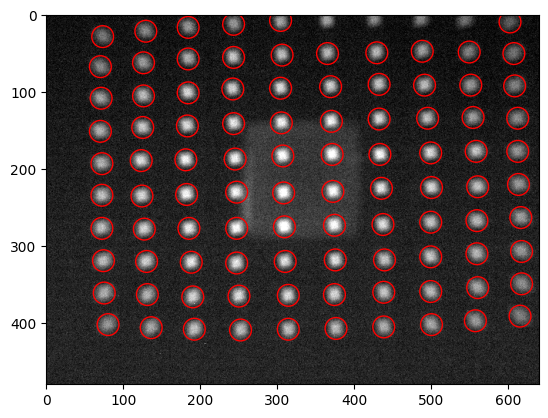

  Processing Pos5.exr …


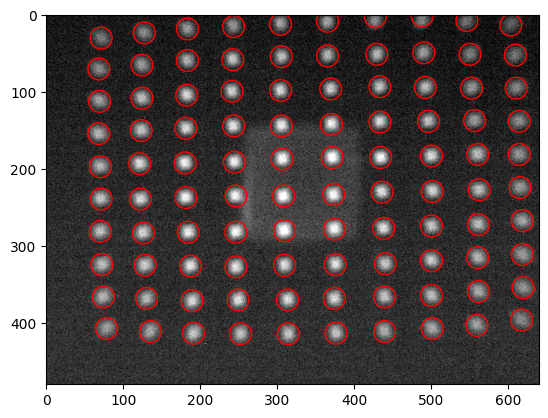

  Processing Pos6.exr …


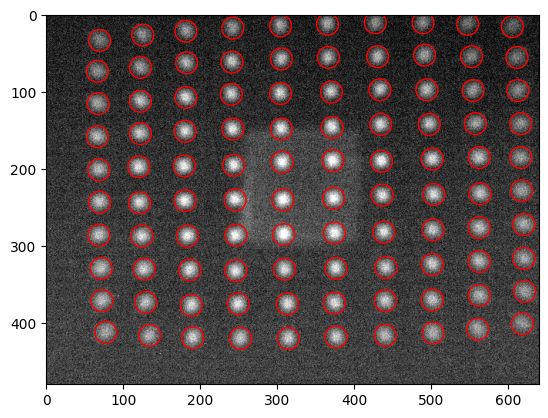

  Processing Pos7.exr …


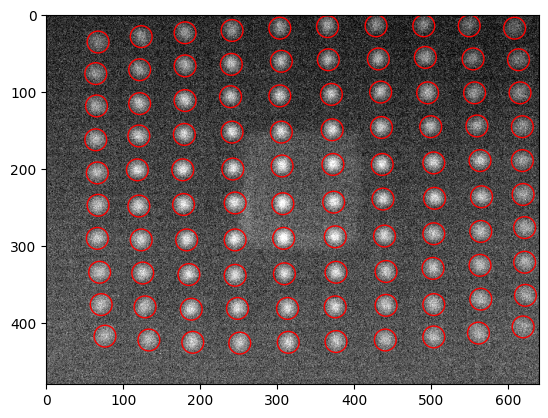

  Processing Pos8.exr …


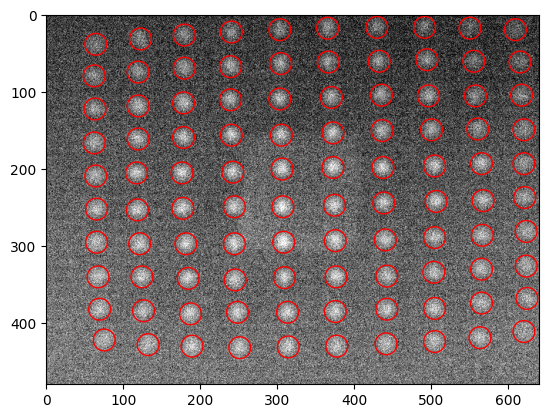

  Processing Pos9.exr …


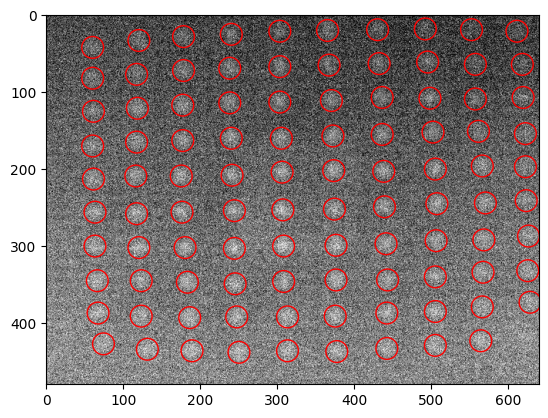


Dots per distance (raw, no grid enforced): [92, 93, 93, 94, 96, 100, 100, 100, 100, 99]
Tracked roster size: 100 dots
IDed dots per distance: [92, 93, 93, 94, 96, 100, 100, 100, 100, 99]


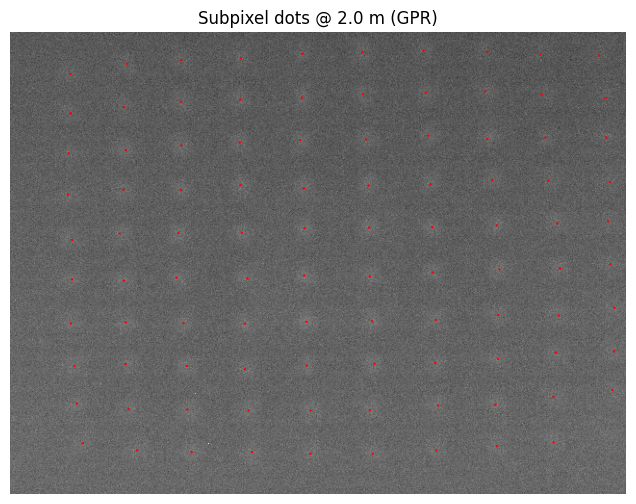

In [2]:
# Collect calibration PCD paths sorted by distance. Pattern and any excluded
# frames come from calibrate.CAMERAS (e.g. Pos9 @3.8 m unwraps wrongly).
EXCLUDE = set(cfg.get("exclude", ()))
pcd_files = sorted(
    (p for p in tof_cal.glob(cfg.get("pcd_glob", "ToF_*m.pcd"))
     if p.stem not in EXCLUDE),
    key=lambda p: calibrate.distance_for(cfg, dotCal, p) or 999.0
)

tof_paths = [str(p) for p in pcd_files]
cal_dists = [calibrate.distance_for(cfg, dotCal, p) for p in tof_paths]
print(f"Calibration distances: {cal_dists}")

# ── Steps 1+2: LoG blob detection + GPR subpixel refinement ─────────────
subpixel_list_unordered = []
for tof_p in tof_paths:
    sl_p = calibrate.find_sl_image(sl_cal, Path(tof_p).name)
    print(f"  Processing {Path(sl_p).name} …")
    blobs, image = dotCal.detect_blobs(str(sl_p), visualize=True, **CAL_BLOB_PARAMS)
    _, subpixels = dotCal.detect_subpixel_locations(blobs, image, mode=SUBPIXEL_MODE)
    subpixel_list_unordered.append(subpixels)

print(f"\nDots per distance (raw, no grid enforced): "
      f"{[len(s) for s in subpixel_list_unordered]}")

# ── Step 2b: cross-distance NN tracking -> stable IDs (Godbaz 4.1) ────────
subpixel_list = dotCal.track_dots_across_distances(
    subpixel_list_unordered, ref_idx=0, threshold_factor=0.5)

n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
print(f"Tracked roster size: {n_dots} dots")
print(f"IDed dots per distance: {[len(s) for s in subpixel_list]}")

# ── Visualize last calibration distance ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image, cmap="gray", alpha=0.8)
for d in subpixel_list[-1]:
    ax.add_patch(plt.Circle((d["x"], d["y"]), 0.5,
                            edgecolor="red", facecolor="none", linewidth=1))
ax.set_title(f"Subpixel dots @ {cal_dists[-1]} m ({SUBPIXEL_MODE})")
ax.axis("off")
calibration_figures.append(("step1_2_subpixel_dots", fig))
plt.show()

## Calibration Step 2c: X/Y Travel-Mode Detection

Detecting if the baseline travels in the x or y direction. (Simulatin: X, Real: Y)

With *TRACK_IN_TX_SPACE = True* the dots are re-tracked in the (approximately parallax
invariant) transmitter space using the derived baseline guess, as in the paper.

In [3]:
mode_info = dotCal.detect_travel_mode(subpixel_list, cal_dists, K)
mode = mode_info["mode"]
B_guess_vec = mode_info["B_guess_vec"]
print(f"Travel mode: {mode}")
print(f"du/dw = {mode_info['du_dw']:.2f} px·m,  dv/dw = {mode_info['dv_dw']:.2f} px·m")
print(f"Signed baseline estimate along {mode}: {mode_info['B_axis_est']*100:.3f} cm")
print(f"Signed baseline estimate along z: {mode_info['B_z_est']*100:.3f} cm "
      f"(from {mode_info['n_fit']} dots)")
print(f"B_guess_vec = {B_guess_vec}")

if TRACK_IN_TX_SPACE:
    coords_list = dotCal.tx_space_coords(
        subpixel_list_unordered, tof_paths, K=K, baseline_guess=B_guess_vec)
    subpixel_list = dotCal.track_dots_across_distances(
        subpixel_list_unordered, ref_idx=0, threshold_factor=0.5,
        coords_list=coords_list, travel_mode=mode)
    n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
    print(f"Re-tracked in transmitter space: roster {n_dots} dots")

Travel mode: y
du/dw = 0.14 px·m,  dv/dw = -18.92 px·m
Signed baseline estimate along y: -3.760 cm
Signed baseline estimate along z: 3.139 cm (from 100 dots)
B_guess_vec = [ 0.00083253 -0.03760109  0.0313942 ]


## Calibration Step 3: 3-D Back-Projection

For each detected dot at pixel (u, v), the iToF measurement is sampled
bilinearly to obtain the 3-D point U_ij in camera coordinates; U_tx = U − B_guess.

U shape:    (100, 10, 3)     (n_dots × n_dist × xyz)
U_tx shape: (100, 10, 3)  (shifted by B_guess = [ 0.00083253 -0.03760109  0.0313942 ])


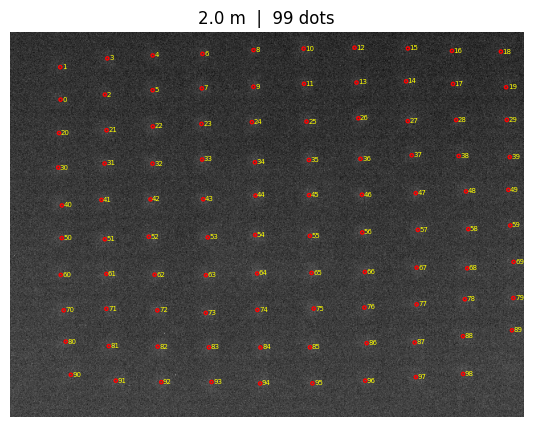

In [4]:
U, U_tx = dotCal.backproject_calibration_dots(
    subpixel_list, tof_paths, K=K,
    pcd_depth_mode="radial",
    baseline_guess=B_guess_vec,
    tof_sample=TOF_SAMPLE,       # "annulus" on the real rig: the projector is on
)                                # during the ToF capture and saturates the dots
print(f"U shape:    {U.shape}     (n_dots × n_dist × xyz)")
print(f"U_tx shape: {U_tx.shape}  (shifted by B_guess = {B_guess_vec})")

# ── Plot: dot IDs at the farthest distance ─────────────────────────────
sl_far = calibrate.find_sl_image(sl_cal, Path(tof_paths[-1]).name)
img = dotCal.read_image(str(sl_far))
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(img, cmap="gray")
for dot in subpixel_list[-1]:
    ax.add_patch(plt.Circle((dot["x"], dot["y"]), 2,
                            edgecolor="red", facecolor="none", linewidth=1))
    ax.text(dot["x"] + 2, dot["y"] + 2, str(dot["id"]),
            fontsize=5, color="yellow")
ax.set_title(f"{cal_dists[-1]} m  |  {len(subpixel_list[-1])} dots")
ax.axis("off")
calibration_figures.append((f"step3_dotids_{cal_dists[-1]}m", fig))
plt.show()

## Calibration Step 4: Baseline Estimation (full 3-D)

Fit a 3D line through each dots calibration distance (in U_tx space), then find
the least-squares intersection of all lines. The full 3D intersection in the origin corrects the
initial guess: `B = B_guess + intersection`.

Multi-stage outlier removal (Godbaz 4.1): dots observed at fewer than `MIN_TRACK_POINTS`
distances contribute no line. With `BASELINE_OUTLIER_SIGMA` set, outlier rays are removed
before the final fit ("After removing outlier rays, the baseline AB is found by an
additional least squares optimization").

Fitted 91 dot lines (after outlier removal)
LS intersection (U_tx):  [ 0.00011599 -0.00053294  0.00135558]
B = [ 0.00094852 -0.03813404  0.03274978]   (AB along y: -3.8134 cm)


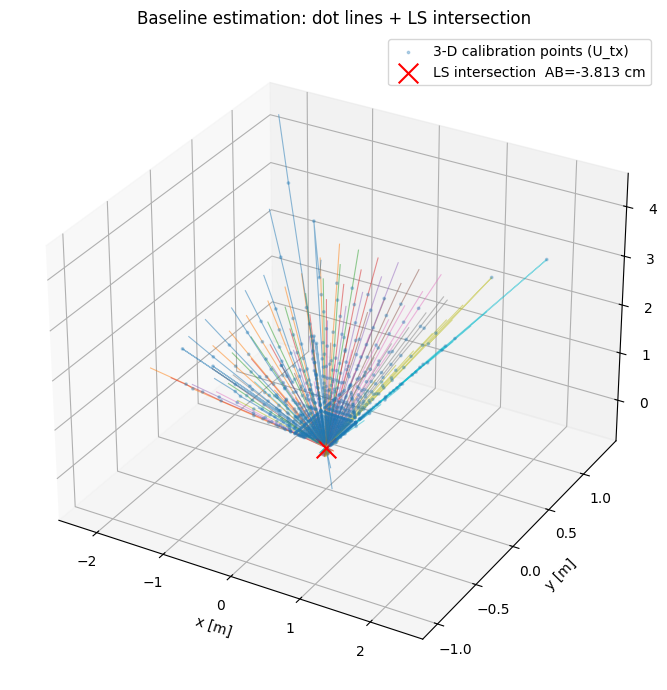

In [5]:
intersection, n_lines = dotCal.estimate_baseline(
    U_tx, outlier_sigma=BASELINE_OUTLIER_SIGMA, min_points=MIN_TRACK_POINTS)

B  = B_guess_vec + intersection
axis = 0 if mode == "x" else 1
AB = float(B[axis])

print(f"Fitted {n_lines} dot lines (after outlier removal)")
print(f"LS intersection (U_tx):  {intersection}")
print(f"B = {B}   (AB along {mode}: {AB*100:.4f} cm)")

# ── 3-D plot: points + lines + intersection ─────────────────────────────
all_pts = U_tx.reshape(-1, 3)
all_pts = all_pts[np.all(np.isfinite(all_pts), axis=1)]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(all_pts[:, 0], all_pts[:, 1], all_pts[:, 2],
           s=3, alpha=0.3, label="3-D calibration points (U_tx)")
cmap = plt.cm.tab10
for i in range(U_tx.shape[0]):
    pts = U_tx[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    if valid.sum() < 2:
        continue
    pts_v = pts[valid]
    direction = pts_v[-1] - pts_v[0]
    extended = np.vstack([(pts_v[0] - 0.3 * direction)[None, :], pts_v,
                          (pts_v[-1] + 0.3 * direction)[None, :]])
    ax.plot(extended[:, 0], extended[:, 1], extended[:, 2],
            color=cmap(i % 10), alpha=0.5, linewidth=0.8)
ax.scatter(*intersection, s=200, marker="x", color="red",
           label=f"LS intersection  AB={AB*100:.3f} cm")
ax.set_title("Baseline estimation: dot lines + LS intersection")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step4_baseline_3d", fig))
plt.show()

## Calibration Step 5: Unit Vector Estimation

For each dot i, fit a unit direction vector V[i] by minimising the angle between
the fitted ray and each calibration point Q_ij = U_ij − B (dots entering/leaving the FOV still get a V).

Unit vectors estimated: 100 / 100


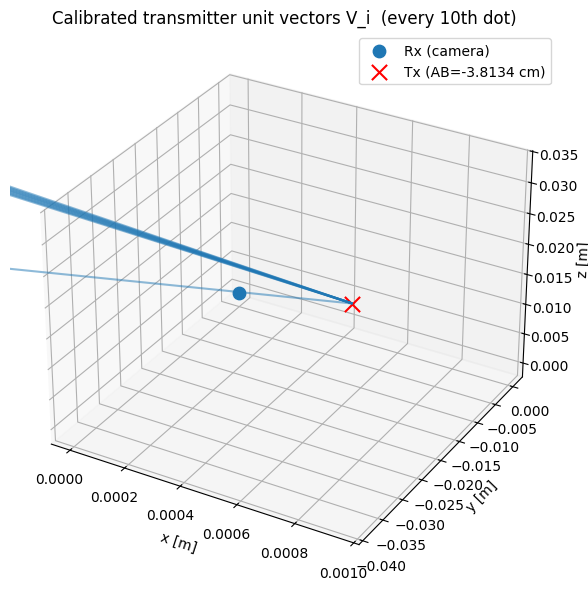

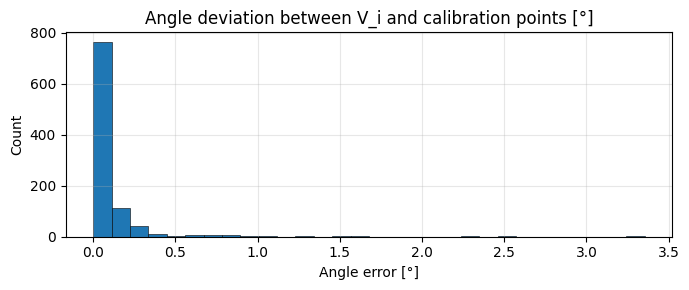

Median angle error: 0.05759°
Max angle error:    3.35419°


In [6]:
V = dotCal.estimate_unit_vectors(U, B)
V_valid = V[np.all(np.isfinite(V), axis=1)]
print(f"Unit vectors estimated: {len(V_valid)} / {V.shape[0]}")

angle_errs = []
for i in range(V.shape[0]):
    if not np.all(np.isfinite(V[i])):
        continue
    pts   = U[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    Q     = pts[valid] - B[None, :]
    Qn    = Q / (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12)
    angle_errs.extend(np.degrees(np.arccos(np.clip(Qn @ V[i], -1, 1))).tolist())

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter([0], [0], [0], s=80, marker="o", label="Rx (camera)")
ax.scatter([B[0]], [B[1]], [B[2]], s=120, marker="x", color="red",
           label=f"Tx (AB={AB*100:.4f} cm)")
for i in range(0, V.shape[0], 10):
    if not np.all(np.isfinite(V[i])):
        continue
    ax.quiver(B[0], B[1], B[2], V[i, 0], V[i, 1], V[i, 2],
              length=0.4, normalize=True, alpha=0.5)
ax.set_title("Calibrated transmitter unit vectors V_i  (every 10th dot)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step5_unit_vectors", fig))
plt.show()

plt.figure(figsize=(7, 3))
plt.hist(np.array(angle_errs), bins=30, edgecolor="k", linewidth=0.4)
plt.title("Angle deviation between V_i and calibration points [°]")
plt.xlabel("Angle error [°]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout()
calibration_figures.append(("step5_angle_error_hist", plt.gcf()))
plt.show()

print(f"Median angle error: {np.median(angle_errs):.5f}°")
print(f"Max angle error:    {np.max(angle_errs):.5f}°")

## Calibration Step 6: 1-D Dot Trails + Noise Estimates

The dot trails are precomputed as 1D Vector (Godbaz 4.2).

Calibration also measures the noise levels used by Approach 2:
- **σ_u** [px]: residual of all detections to their trail line
- **σ_ToF(z)**: robust std of the dots ToF depths per distance

Trails: 100 dots, 49 samples on average (z: 0.4 m -> ∞)
sigma_u (2-D cal residual) = 0.2449 px
sigma_u_ab (1-D runtime AB) = 0.3465 px
sigma_ToF(z):
  z = 0.402 m  ->  σ = 5.75 mm
  z = 0.437 m  ->  σ = 5.49 mm
  z = 0.482 m  ->  σ = 4.95 mm
  z = 0.539 m  ->  σ = 4.75 mm
  z = 0.612 m  ->  σ = 5.12 mm
  z = 0.709 m  ->  σ = 7.43 mm
  z = 0.851 m  ->  σ = 6.92 mm
  z = 1.052 m  ->  σ = 9.49 mm
  z = 1.378 m  ->  σ = 15.41 mm
  z = 1.993 m  ->  σ = 19.15 mm


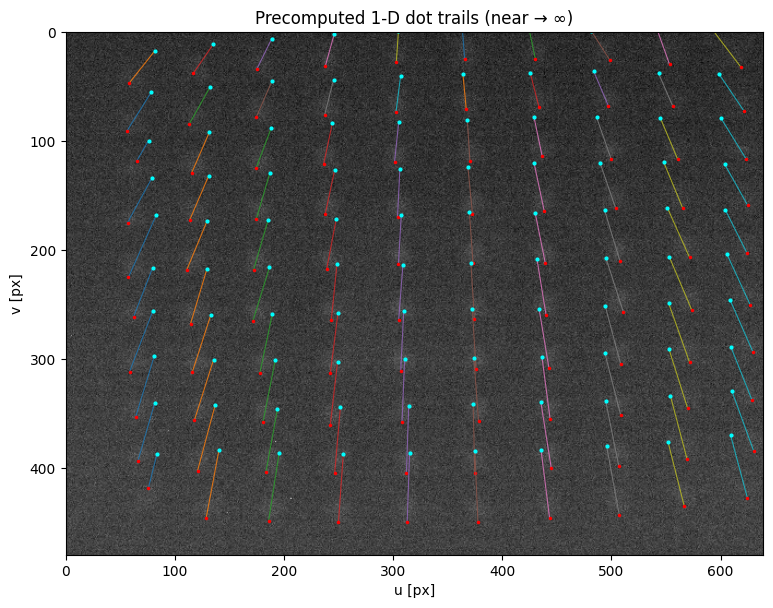

In [7]:
image_shape = image.shape[:2]
TRAIL_Z_MIN = 0.4  # trails run from here to infinity [m] (Godbaz: ~30 cm)
trails = dotCal.fit_trails_from_detections(
    subpixel_list, U, z_min=TRAIL_Z_MIN, step_px=1.0,
    image_shape=image_shape, V=V, B=B, K=K)
n_trails = sum(1 for t in trails if t is not None)
lens = [len(t["u"]) for t in trails if t is not None]
print(f"Trails: {n_trails} dots, {int(np.mean(lens))} samples on average "
      f"(z: {TRAIL_Z_MIN} m -> ∞)")

sigma_u = dotCal.estimate_sigma_u_trails(subpixel_list, trails)
sigma_tof_table = dotCal.estimate_sigma_tof(U, expected_z=cal_dists)
sl_paths = [calibrate.find_sl_image(sl_cal, Path(p).name) for p in tof_paths]
sigma_u_ab = calibrate.estimate_sigma_u_ab(dotCal, subpixel_list, trails, sl_paths, TRAIL_Z_MIN)
print(f"sigma_u (2-D cal residual) = {sigma_u:.4f} px")
print(f"sigma_u_ab (1-D runtime AB) = {sigma_u_ab:.4f} px")
print("sigma_ToF(z):")
for z, s in sigma_tof_table:
    print(f"  z = {z:.3f} m  ->  σ = {s*1e3:.2f} mm")

# ── Trail visualization 
fig = dotCal.plot_dot_trails(trails, image_shape=image_shape, background=image)
calibration_figures.append(("step6_dot_trails", fig))
plt.show()

## Save Calibration

Writes the extended `calibration.json` (incl. mode, full 3-D B, precomputed trails,
σ_u, σ_ToF table) to `Calibrations/<CAL_NAME>/`. Set `CAL_NAME`/`SAVE_PLOTS` below.

In [8]:
import json as _json
from datetime import datetime as _dt

CAL_NAME   = f"{CAMERA}_paperlike"   # -> Calibrations/<CAL_NAME>/calibration.json
SAVE_PLOTS = True

cal_dir = Path.cwd().parent / "Calibrations" / CAL_NAME
cal_dir.mkdir(parents=True, exist_ok=True)

cal_data = calibrate.sanitize({
    "metadata": {
        "created": _dt.now().isoformat(),
        "camera": CAMERA,
        "sl_cal_path": str(sl_cal),
        "tof_cal_path": str(tof_cal),
        "pipeline": "codePaperlike",
        "mode": mode,
        "baseline_guess": B_guess_vec.tolist(),
        "subpixel_mode": SUBPIXEL_MODE,
        "pcd_depth_mode": "radial",
        "tof_sample": TOF_SAMPLE,
        "pcd_unit_scale": 0.001,
        "track_in_tx_space": TRACK_IN_TX_SPACE,
        "baseline_outlier_sigma": BASELINE_OUTLIER_SIGMA,
        "baseline_min_points": MIN_TRACK_POINTS,
        "trail_z_min": TRAIL_Z_MIN,
        "fx": float(fx), "fy": float(fy),
        "cx": float(cx), "cy": float(cy),
    },
    "mode": mode,
    "K": K.tolist(),
    "K_inv": K_inv.tolist(),
    "V": V.tolist(),
    "B": B.tolist(),
    "AB": AB,
    "BASELINE_GUESS": B_guess_vec.tolist(),
    "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "U": U.tolist(),
    "trails": [None if t is None else
               {"u": t["u"].tolist(), "v": t["v"].tolist(), "w": t["w"].tolist()}
               for t in trails],
    "sigma_u": float(sigma_u),
    "sigma_u_ab": float(sigma_u_ab),
    "sigma_tof_table": sigma_tof_table.tolist(),
})

cal_file = cal_dir / "calibration.json"
with open(cal_file, "w") as f:
    _json.dump(cal_data, f)
print(f"Calibration saved to {cal_file}")

if SAVE_PLOTS:
    for name, fig in calibration_figures:
        fig.savefig(str(cal_dir / f"{name}.png"), dpi=150, bbox_inches="tight")
    print(f"Saved {len(calibration_figures)} plot(s) to {cal_dir}")

Calibration saved to /Users/julian/Documents/Github/iToF-SL-Combination/Calibrations/SchmersalReal_paperlike/calibration.json
Saved 6 plot(s) to /Users/julian/Documents/Github/iToF-SL-Combination/Calibrations/SchmersalReal_paperlike


## Test Scene Setup

Load a test scene and the precomputed trails.

Ground-truth distance: 0.5 m
Trails: 100 / 100 dots calibrated (mode: y)


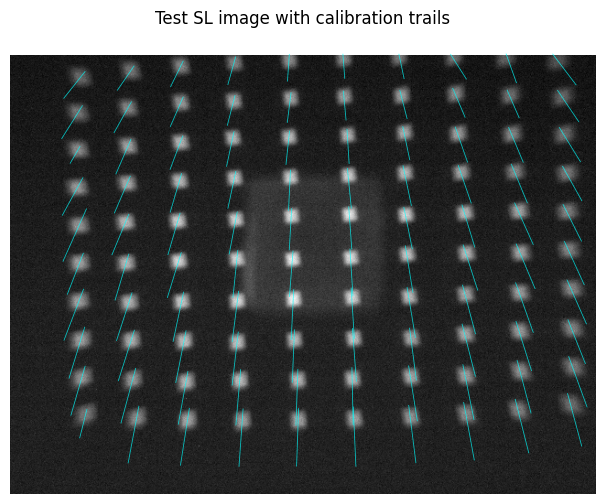

In [9]:
suffix = "_On" if CAMERA == "OnSemi" else "_Schm"
#test_dir = Path(r"C:\Users\Julian\Documents\GitHub\iToF-SL-Combination\Pictures\Test\19.08")
#test_dir = Path("/home/julian/Documents/Github/iToF-SL-Combination/Pictures/Test/FlatWallSchmersalReal")
test_dir = Path("/Users/julian/Documents/Github/iToF-SL-Combination/Pictures/Test/FlatWallSchmersalReal")
SL_TEST  = str(test_dir / f"0.50m.exr")
TOF_TEST = str(test_dir / f"0.50m.pcd")

# Ground truth from filename (e.g. "SL_0.81m.png" -> 0.81m)
approaches.GT_DISTANCE = approaches._parse_gt_distance(SL_TEST)
offset = 0
approaches.GT_DISTANCE = approaches.GT_DISTANCE-offset
print(f"Ground-truth distance: {approaches.GT_DISTANCE} m")

# Calibration dict
cal = {
    "K": K, "K_inv": K_inv, "V": V, "B": B,
    "AB": AB, "mode": mode,
    "U": U, "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "trails": trails,
    "sigma_u": float(sigma_u), "sigma_u_ab": float(sigma_u_ab),
    "sigma_tof_table": sigma_tof_table,
    "metadata": {"pcd_unit_scale": 0.001, "trail_z_min": TRAIL_Z_MIN, "mode": mode},
}

setup = approaches.common_setup(dotCal, cal, SL_TEST, TOF_TEST)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(setup["sl_gray"], cmap="gray")
for t in setup["trails"]:
    if t is not None:
        ax.plot(t["u"], t["v"], lw=0.6, alpha=0.7, color="cyan")
ax.set_title("Test SL image with calibration trails"); ax.axis("off"); plt.show()

## Approach 1: Consistency Error  (Microsoft-Paper §4.2)

Pure trail scan, no dot localisation, no runtime triangulation. For every calibrated dot
trail, the ToF depth image is resampled along the trail. the sample k\* = argmin ε with
**ε = |1/Z_ToF − 1/Z_tri|** (Z_tri precomputed per sample) is selected and the **ToF depth**
at k\* is returned. Dots with ε\* above `approaches.EPS_THRESHOLD` are invalidated.
The reported standard deviation σ (especially meaningful on planar scenes) is printed in the legend of the figures.

Approach 1: scanned 100 trails (2 invalidated by ε-threshold 0.1)
  ε range: 1.446e-04 – 9.455e-02
  Z_out (ToF @ min-ε): n=98/100  mean=0.4958 m  σ=6.34 mm

  ** Approach 1 — Average Error **
     GT distance:  0.5000 m
     Valid dots:   98 / 100
     Mean error:   -0.0042 m
     Mean |error|: 0.0063 m
     Std error:    0.0063 m
     Min error:    -0.0120 m
     Max error:    +0.0196 m
AVG_ERR|1|0.5000|98|100|-0.004227|0.006338|0.006335|-0.012043|0.019644


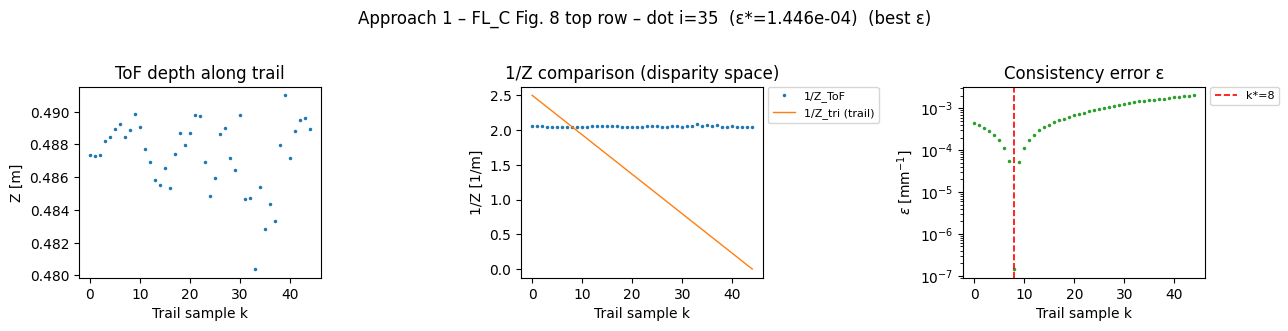

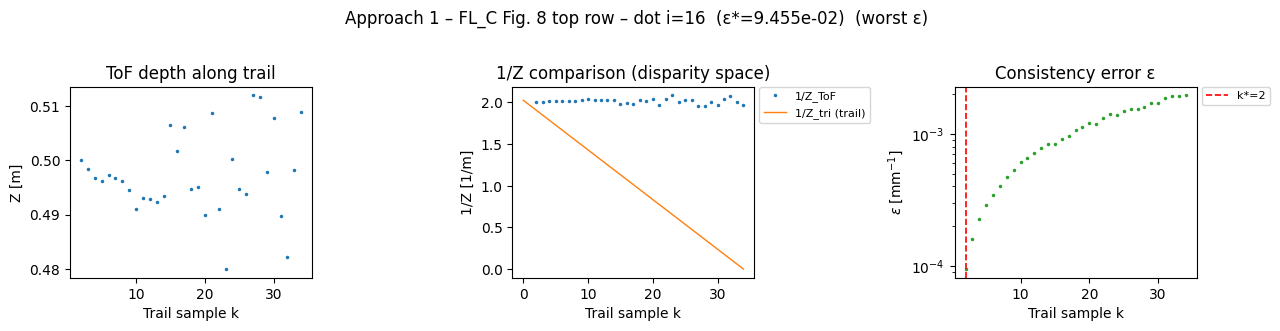

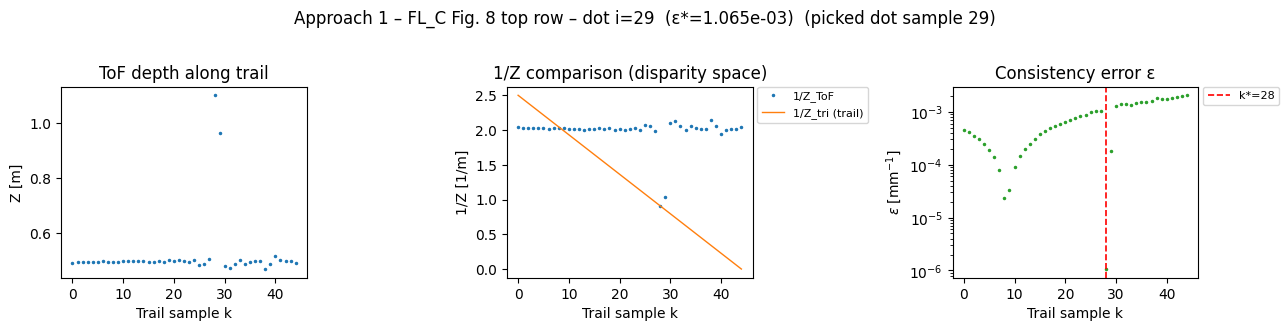

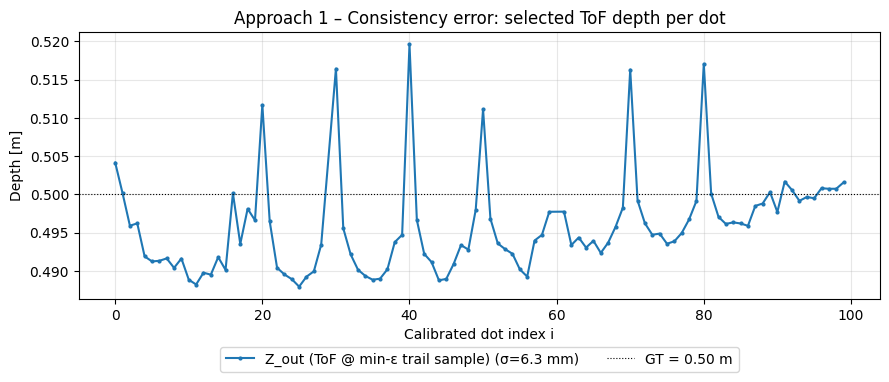

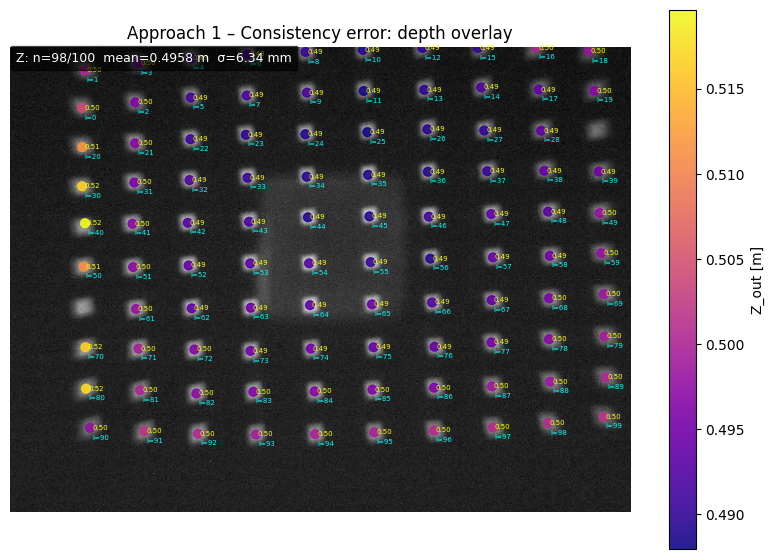

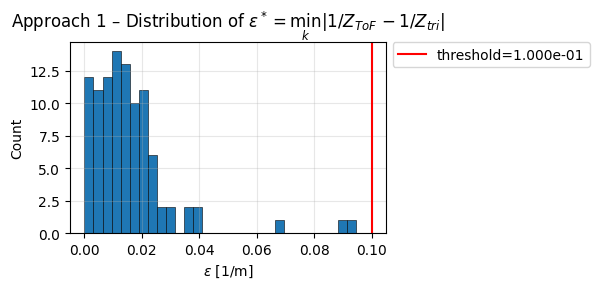

In [ ]:


res1 = approaches.run_approach_1(dotCal, cal, setup, make_plots=True, dot_sample=[29,60], exclude=[29,60])
approaches.print_average_error(1, res1["depths"])
plt.show()

## Approach 2: Gaussian Maximum-Likelihood Fusion  (Agresti & Zanuttigh)

Dot identfication identical to Approach 3 (AB peaks along the trail -> min-ε with iToF -> quadratic
subpixel -> triangulation). Then each modality is modelled as **one Gaussian**. (Removed 7x7 windowed Gaussian, not needed, because we do not use SL phase information and have exactly one pixel position -> no weighted Gaussian)

- σ_SL = z²/(‖B‖·f)·σ_u  (calibrated σ_u -> Agresti's d⁴/B² variance scaling)
- σ_ToF(z) interpolated from the calibration flat-wall noise table

The joint likelihood is the product of the two Gaussians. The depth at its maximum
(precision-weighted mean) is returned. Standard deviations for **SL, iToF and the joint
estimate** are printed as well.

Approach 2: 100 trails, 89 fused depths
  SL (triangulated): n=97/100  mean=0.5034 m  σ=32.97 mm
  iToF: n=97/100  mean=0.5047 m  σ=91.75 mm
  Joint likelihood: n=89/100  mean=0.4950 m  σ=7.27 mm
  mean predicted σ_SL: 4.42 mm
  mean predicted σ_ToF: 4.90 mm
  mean predicted σ_joint: 3.24 mm

  ** Approach 2 — Average Error **
     GT distance:  0.5000 m
     Valid dots:   89 / 100
     Mean error:   -0.0050 m
     Mean |error|: 0.0073 m
     Std error:    0.0073 m
     Min error:    -0.0148 m
     Max error:    +0.0242 m
AVG_ERR|2|0.5000|89|100|-0.004988|0.007345|0.007268|-0.014751|0.024223


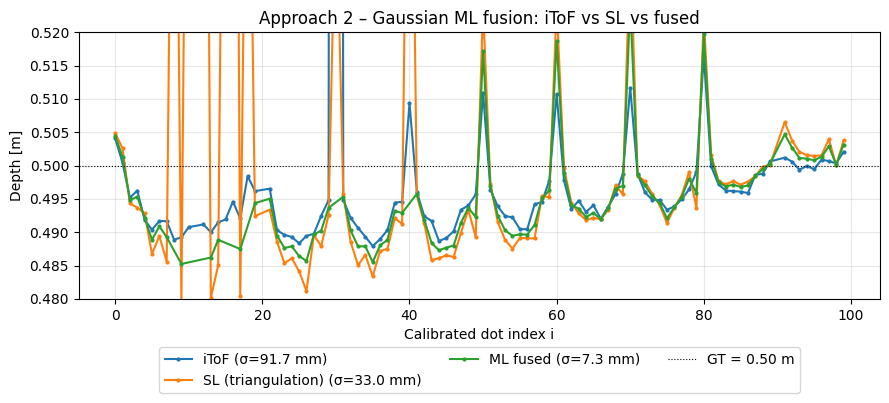

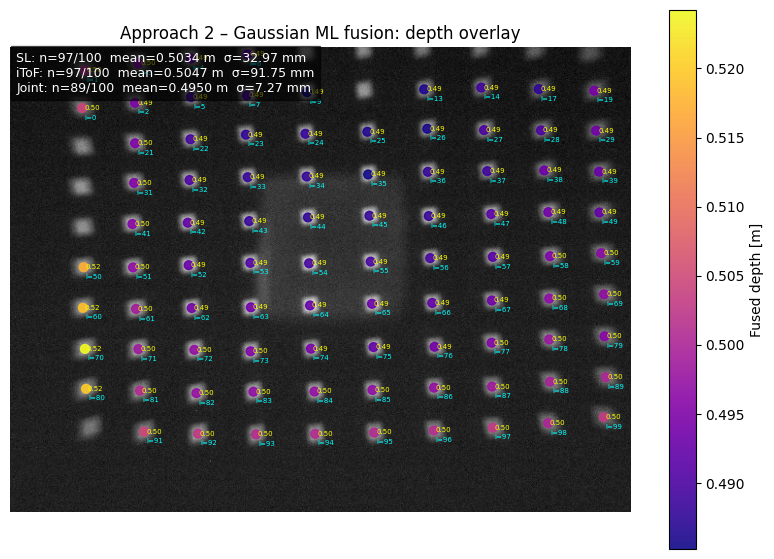

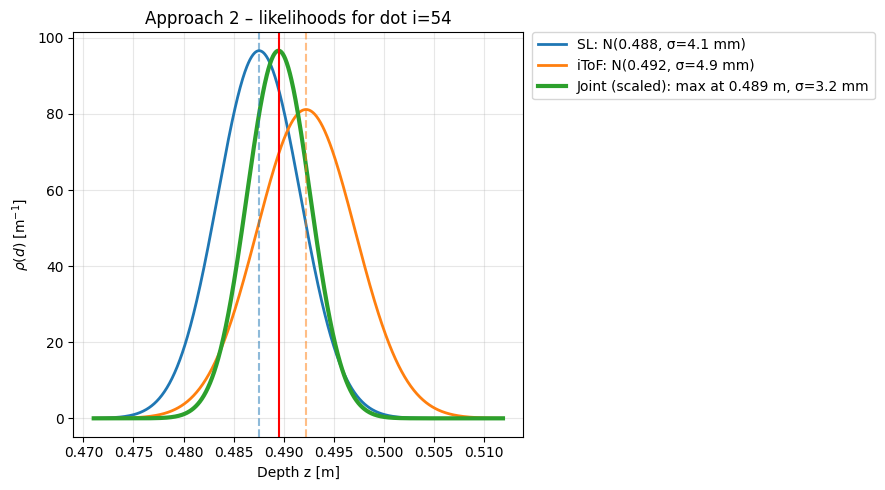

In [11]:
res2 = approaches.run_approach_2(dotCal, cal, setup, make_plots=True, limit = [0.48,0.52])
approaches.print_average_error(2, res2["depths"])
plt.show()

## Approach 3: Active Brightness Trail  (Microsoft-Paper §4.2)

1. Resample the active brightness along each dot trail (1-D vector)
2. Peak finding (relative prominence, trails intersect, multiple peaks expected)
3. Select the peak minimising ε = |1/Z_ToF − 1/Z_tri| (iToF resolves the ambiguity)
4. Subpixel via a **locally fitted quadratic** on the 1-D AB signal (2D GPR also possible, as Godbaz states in the paper)
5. Return the **triangulated** depth at the refined position.

Approach 3: 100 trails (3 without AB peaks, 11 invalid after ε-gate)
  Z_out (triangulated): n=89/100  mean=0.4944 m  σ=9.21 mm

  ** Approach 3 — Average Error **
     GT distance:  0.5000 m
     Valid dots:   89 / 100
     Mean error:   -0.0056 m
     Mean |error|: 0.0087 m
     Std error:    0.0092 m
     Min error:    -0.0208 m
     Max error:    +0.0338 m
AVG_ERR|3|0.5000|89|100|-0.005560|0.008656|0.009206|-0.020818|0.033812


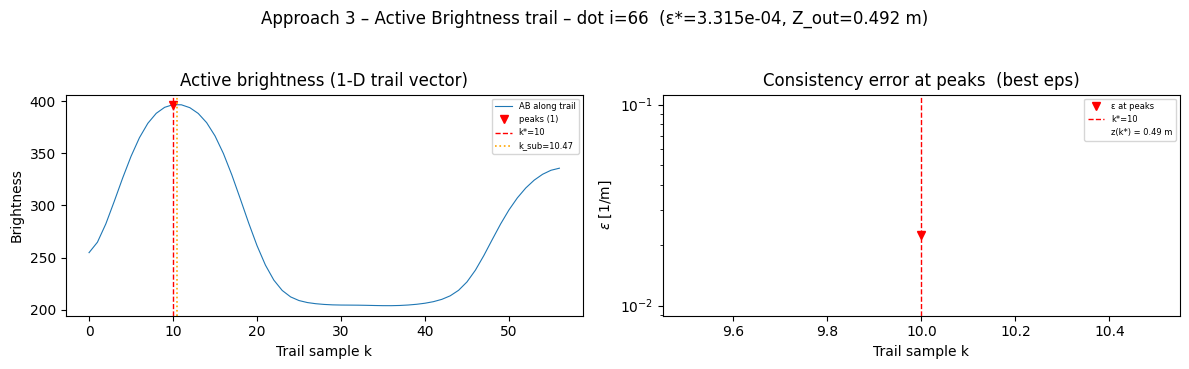

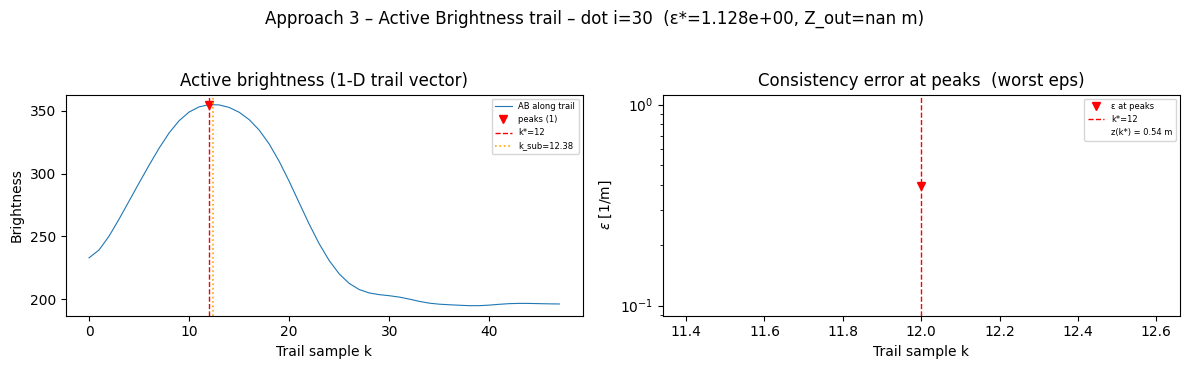

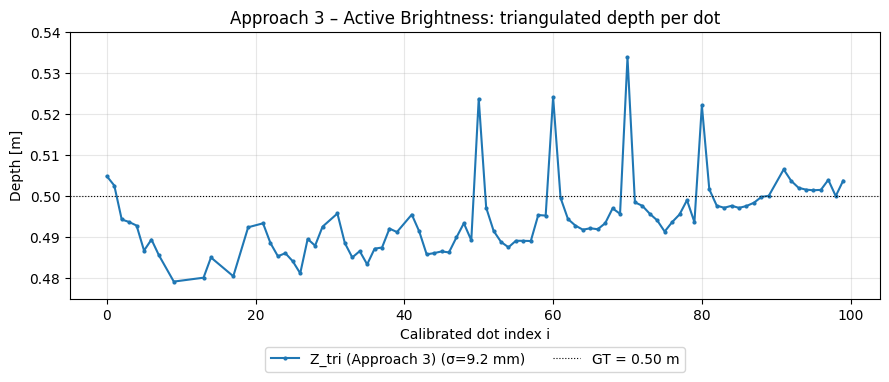

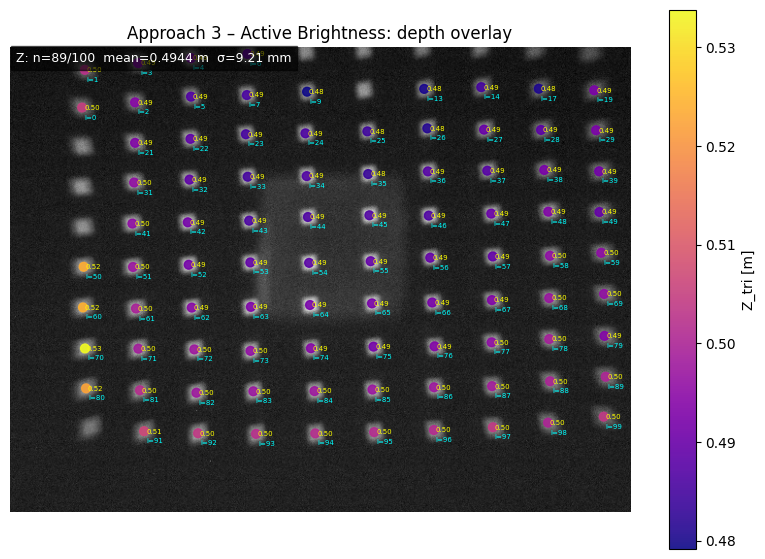

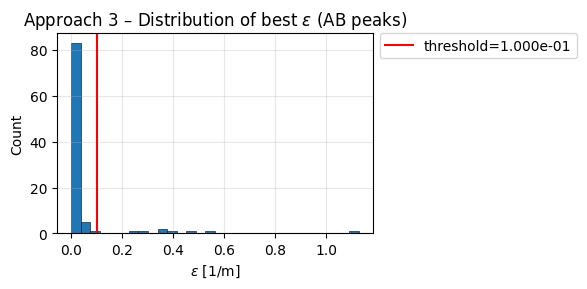

In [12]:

res3 = approaches.run_approach_3(dotCal, cal, setup, make_plots=True,limit=[0.475,0.54])
approaches.print_average_error(3, res3["depths"])
plt.show()